# Native likelihood: site-blocking (SIMD) benchmark

The native op takes a `block_size` parameter. With `block_size=1` (the default)
sites are processed one at a time, reproducing the original traversal. With
`block_size>1` that many sites are transposed into a contiguous,
site-innermost scratch layout so the per-node transition-matrix products become
AXPY loops the compiler can vectorise with SIMD (and each transition matrix is
loaded once per node per block instead of once per site).

The result is **bit-identical** regardless of `block_size` -- this only affects
performance. This notebook sweeps `block_size` against the TensorFlow reference
so you can pick a value (or confirm `1`) for your hardware.

> Note: on a 4-core cloud container with nucleotide (S=4) data the blocked path
> was performance-neutral -- the kernel is memory-movement bound there, not
> compute bound. Vectorising the arithmetic helps most when compute dominates
> (larger state counts, more cores, wider SIMD), so re-measure on your target
> machine.

In [2]:
from treeflow.acceleration.native import phylo_likelihood as native_mod

if not native_mod.is_available():
    from treeflow.acceleration.native.build import build
    build()
print("native op available:", native_mod.is_available())

native op available: True


In [3]:
import time
import numpy as np
import tensorflow as tf

from treeflow.tree.topology.numpy_tree_topology import NumpyTreeTopology, StaticNumpyTreeTopology
from treeflow.tree.topology.tensorflow_tree_topology import numpy_topology_to_tensor
from treeflow.traversal.phylo_likelihood import phylogenetic_likelihood as reference
from treeflow.acceleration.native import native_phylogenetic_likelihood as native

tf.get_logger().setLevel("ERROR")

In [8]:
def make_problem(leaf_count, state_count, site_count, seed=0, dtype=tf.float64):
    rng = np.random.default_rng(seed)
    node_count = 2 * leaf_count - 1
    parent = np.full(node_count, -1, dtype=np.int32)
    active = list(range(leaf_count))
    nxt = leaf_count
    while len(active) > 1:
        a = active.pop(rng.integers(len(active)))
        b = active.pop(rng.integers(len(active)))
        parent[a] = parent[b] = nxt
        active.append(nxt)
        nxt += 1
    topology = numpy_topology_to_tensor(NumpyTreeTopology(parent_indices=parent[:-1]))
    states = rng.integers(0, state_count, size=(site_count, leaf_count))
    sequences = tf.constant(np.eye(state_count, dtype=dtype.as_numpy_dtype)[states])
    probs = rng.uniform(0.1, 1.0, size=(1, node_count, state_count, state_count))
    probs /= probs.sum(axis=-1, keepdims=True)
    probs = tf.constant(probs, dtype=dtype)
    freqs = tf.constant(np.full(state_count, 1.0 / state_count), dtype=dtype)
    return dict(sequences=sequences, transition_probs=probs, frequencies=freqs,
                postorder=topology.postorder_node_indices,
                child_indices=topology.node_child_indices, topology=topology)

In [11]:
import statistics

def timeit(fn, *args, repeats=30, **kwargs):
    fn(*args, **kwargs)  # warm up / trace
    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        out = fn(*args, **kwargs)
        tf.nest.map_structure(lambda t: t.numpy(), out)
        samples.append((time.perf_counter() - start) * 1e3)  # ms
    return statistics.median(samples)


def native_fns(block_size):
    ll = tf.function(lambda *a: native(*a, block_size=block_size))

    @tf.function
    def vg(seq, probs, freqs, po, ci):
        with tf.GradientTape() as tape:
            tape.watch(probs)
            loss = tf.reduce_sum(tf.math.log(
                native(seq, probs, freqs, po, ci, block_size=block_size)))
        return loss, tape.gradient(loss, probs)
    return ll, vg


def benchmark(leaf_count, site_count, block_sizes, state_count=4, seed=0):
    p = make_problem(leaf_count, state_count, site_count, seed=seed)
    batch = tf.shape(p["sequences"])[:1]
    args = (p["sequences"], p["transition_probs"], p["frequencies"],
            p["postorder"], p["child_indices"])
    tf_args = (p["topology"], p["sequences"], p["transition_probs"], p["frequencies"])

    ref_ll = tf.function(lambda *a: reference(*a, batch_shape=batch))
    @tf.function
    def ref_vg(probs):
        with tf.GradientTape() as tape:
            tape.watch(probs)
            loss = tf.reduce_sum(tf.math.log(
                reference(p["topology"], p["sequences"], probs, p["frequencies"], batch_shape=batch)))
        return loss, tape.gradient(loss, probs)

    row = dict(leaf_count=leaf_count, site_count=site_count,
               ref_ll=timeit(ref_ll, *tf_args),
               ref_grad=timeit(ref_vg, p["transition_probs"]))
    for bs in block_sizes:
        ll, vg = native_fns(bs)
        row[f"ll_{bs}"] = timeit(ll, *args)
        row[f"grad_{bs}"] = timeit(vg, *args)
    return row

## Run the sweep

In [14]:
BLOCK_SIZES = [1, 8, 16, 32]
configs = [(64, 1000), (128, 2000), (256, 4000), (512, 4000), (512, 8000)]
rows = [benchmark(L, sites, BLOCK_SIZES) for (L, sites) in configs]

cols = "  ".join(f"ll@{bs:<2}" for bs in BLOCK_SIZES)
print(f"{'leaves':>6} {'sites':>6} | {'ref ll':>8} | " + cols)
print("-" * 70)
for r in rows:
    times = "  ".join(f"{r[f'll_{bs}']:5.2f}" for bs in BLOCK_SIZES)
    print(f"{r['leaf_count']:>6} {r['site_count']:>6} | {r['ref_ll']:>8.2f} | {times}")

print()
cols = "  ".join(f"grad@{bs:<2}" for bs in BLOCK_SIZES)
print(f"{'leaves':>6} {'sites':>6} | {'ref grad':>8} | " + cols)
print("-" * 74)
for r in rows:
    times = "  ".join(f"{r[f'grad_{bs}']:6.2f}" for bs in BLOCK_SIZES)
    print(f"{r['leaf_count']:>6} {r['site_count']:>6} | {r['ref_grad']:>8.2f} | {times}")

leaves  sites |   ref ll | ll@1   ll@8   ll@16  ll@32
----------------------------------------------------------------------
    64   1000 |    12.42 |  0.33   0.41   0.39   0.38
   128   2000 |    29.92 |  0.45   0.90   0.74   0.69
   256   4000 |    83.83 |  2.94   4.58   4.11   3.83
   512   4000 |   245.55 |  7.09   9.13   8.71   8.06
   512   8000 |   505.79 | 21.05  27.36  24.63  23.94

leaves  sites | ref grad | grad@1   grad@8   grad@16  grad@32
--------------------------------------------------------------------------
    64   1000 |     5.46 |   0.74    0.77    0.77    0.83
   128   2000 |    14.10 |   1.98    2.25    1.75    2.04
   256   4000 |    52.80 |   8.93    9.40    8.60    8.69
   512   4000 |   128.45 |  20.65   20.50   17.88   18.50
   512   8000 |   263.09 |  52.89   48.83   44.41   45.95


## Speedup of each block size over the reference

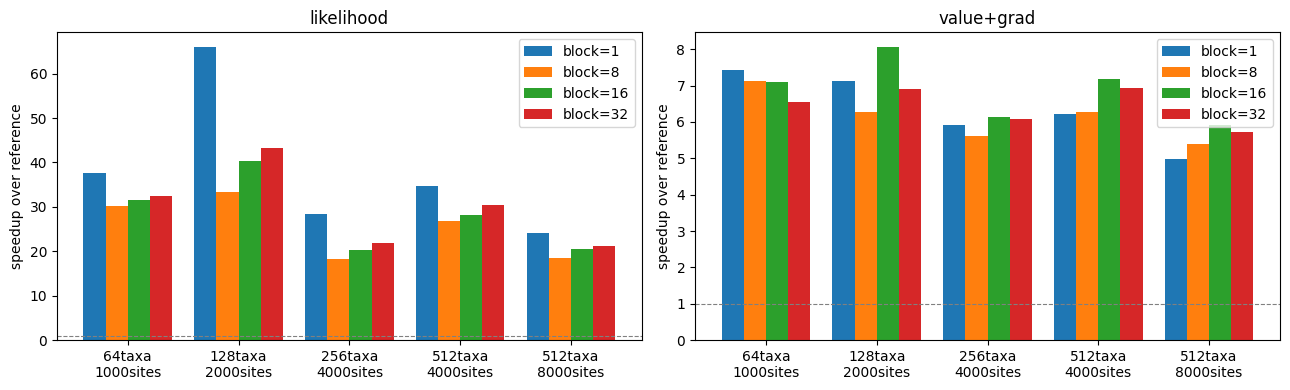

In [15]:
import matplotlib.pyplot as plt

labels = [f"{r['leaf_count']}taxa\n{r['site_count']}sites" for r in rows]
x = np.arange(len(rows))
width = 0.8 / len(BLOCK_SIZES)
fig, (ax_ll, ax_g) = plt.subplots(ncols=2, figsize=(13, 4), sharex=True)
for i, bs in enumerate(BLOCK_SIZES):
    off = (i - (len(BLOCK_SIZES) - 1) / 2) * width
    ax_ll.bar(x + off, [r["ref_ll"] / r[f"ll_{bs}"] for r in rows], width, label=f"block={bs}")
    ax_g.bar(x + off, [r["ref_grad"] / r[f"grad_{bs}"] for r in rows], width, label=f"block={bs}")
for ax, title in [(ax_ll, "likelihood"), (ax_g, "value+grad")]:
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("speedup over reference"); ax.set_title(title)
    ax.axhline(1.0, color="grey", lw=0.8, ls="--"); ax.legend()
fig.tight_layout()

## Notes

* `block_size` is exposed on `native_phylogenetic_likelihood`,
  `native_phylogenetic_log_likelihood_rescaled`, the
  `phylogenetic_log_likelihood` dispatcher (`use_native=True`), and on
  `LeafCTMC(..., block_size=...)`.
* You should be able to pick whichever `block_size` is fastest on your machine with no effect on correctness or inference results.